TARGET ANALYSIS - CHURN

Dataset: 70,000 rows × 26 columns

TARGET VARIABLE DISTRIBUTION

Churn Distribution:
No Churn (0): 40,779 (58.26%)
Churn (1): 29,221 (41.74%)

Churn Rate: 41.74%
Class Imbalance Ratio: 1:1.40


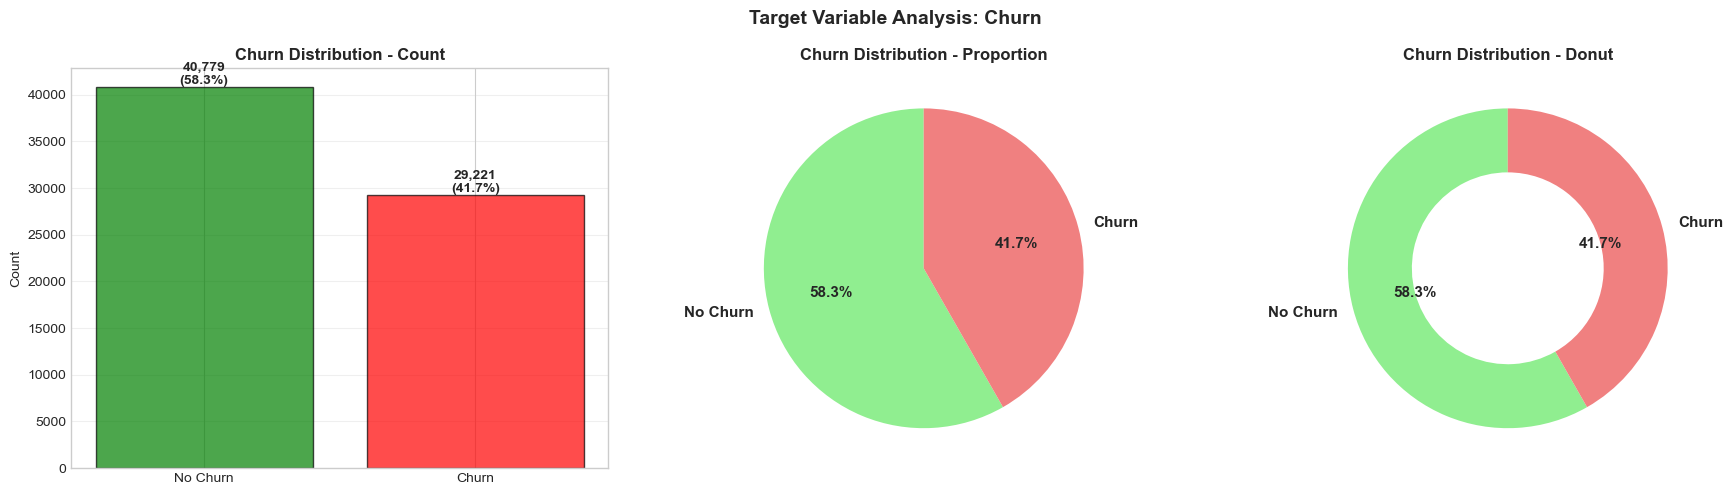


CHURN vs NUMERICAL FEATURES


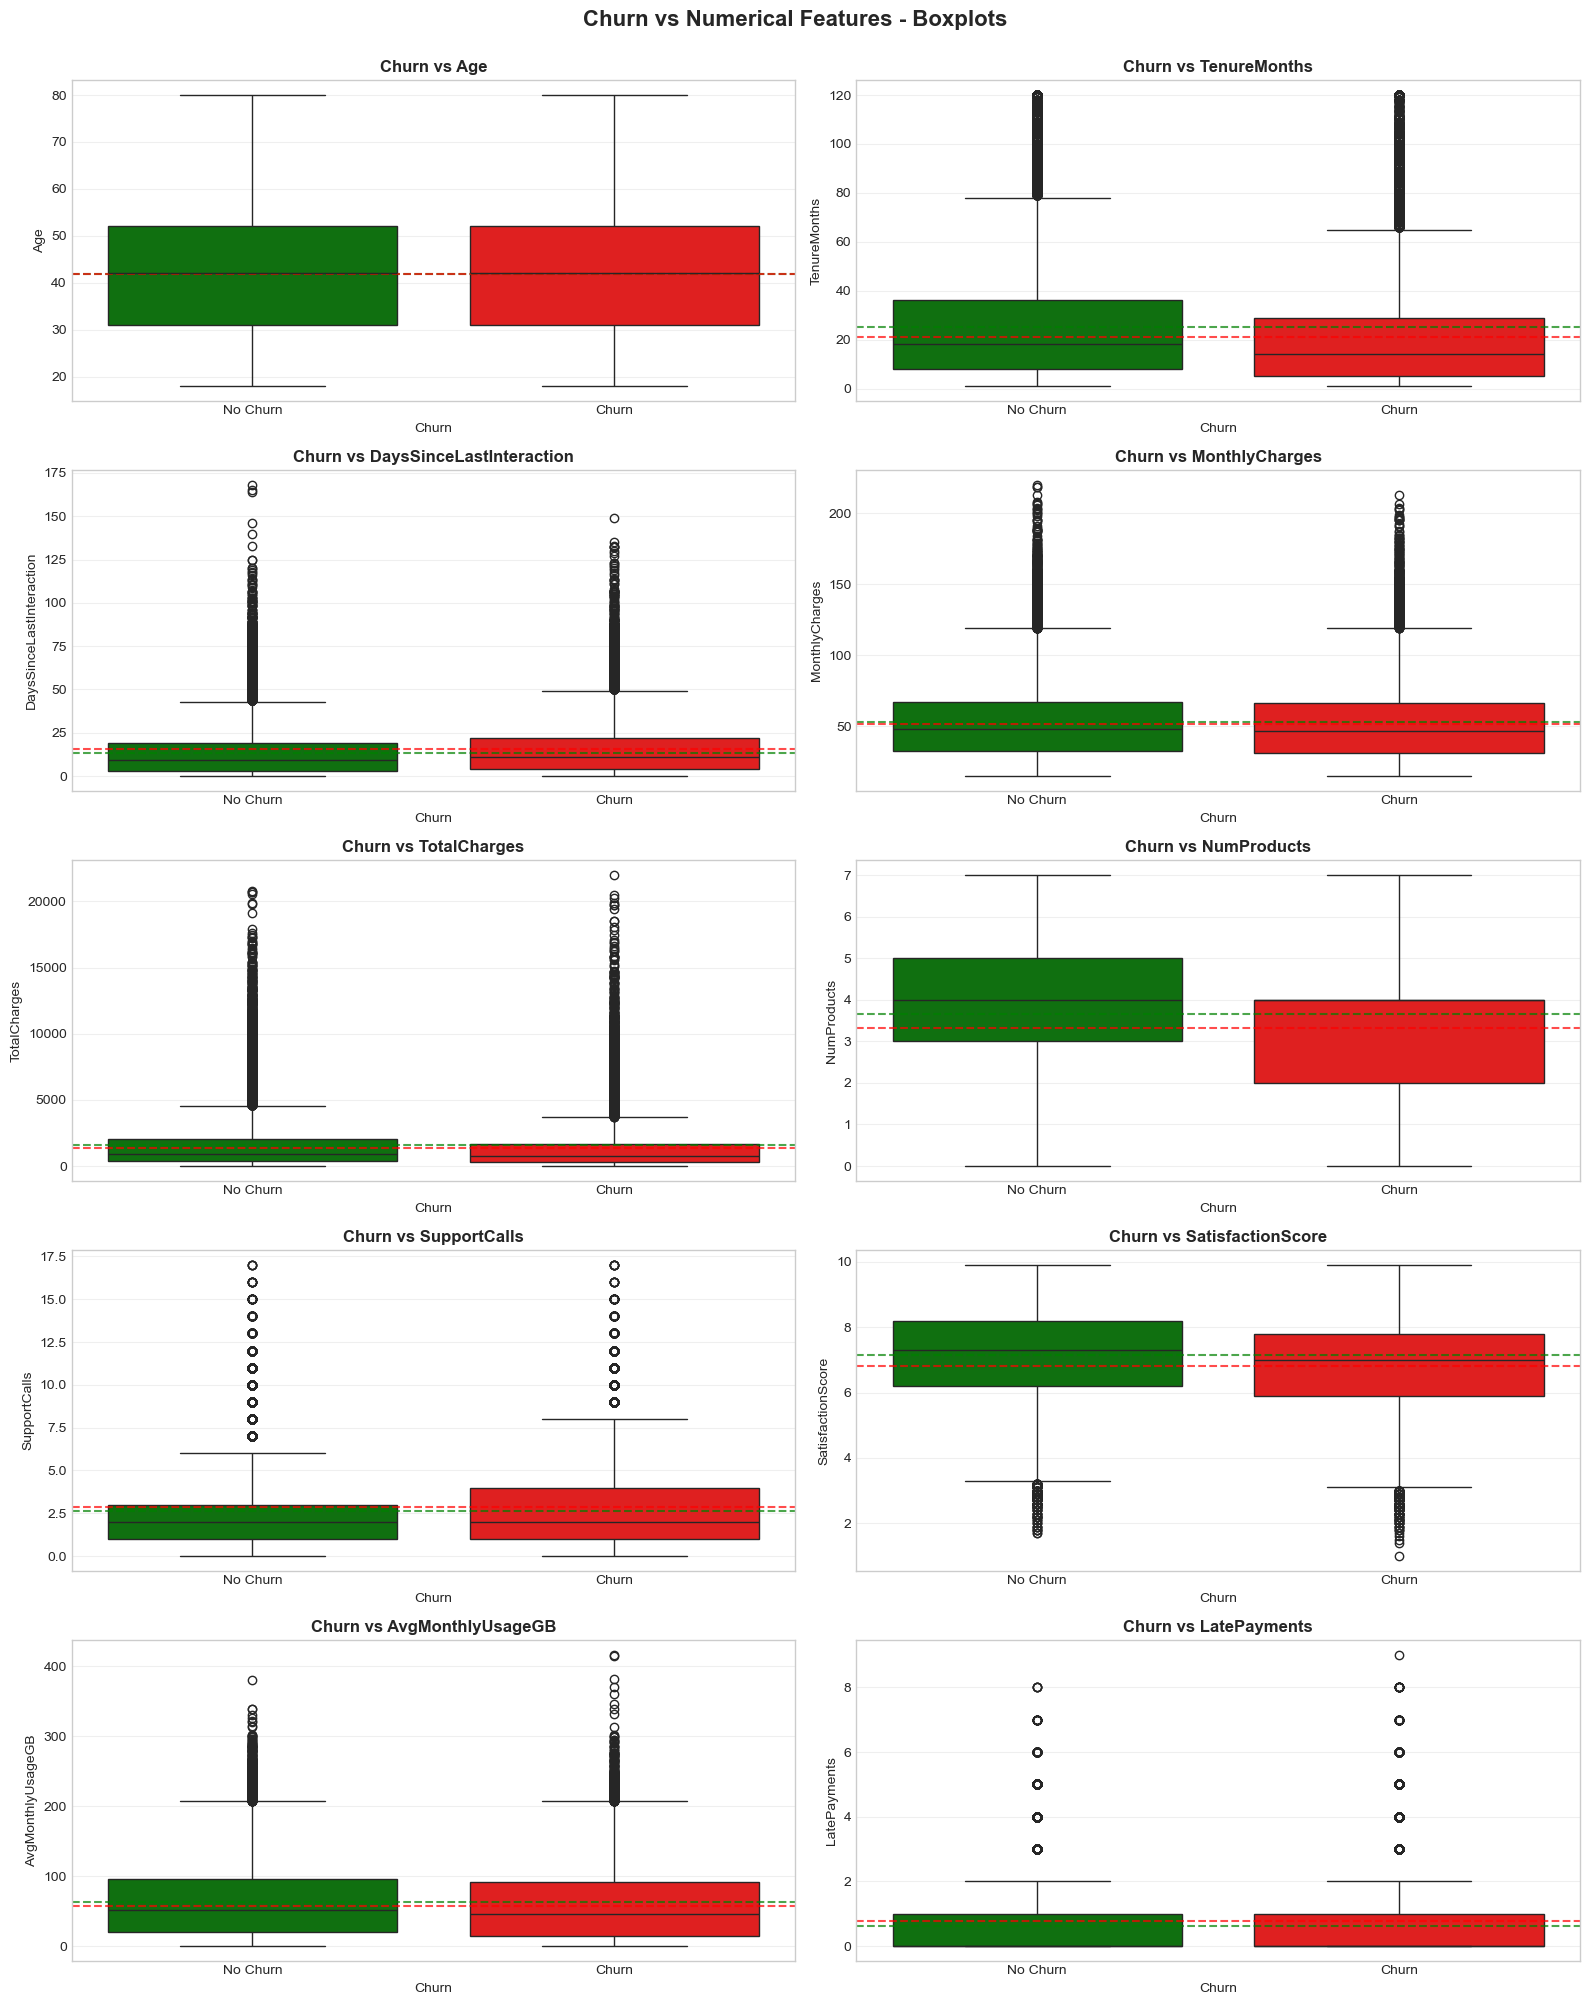


STATISTICAL TESTS - CHURN vs NUMERICAL FEATURES
                 Feature  No Churn Mean  Churn Mean  Mean Diff  T-Test P-Value  Mann-Whitney P-Value Significant
            TotalCharges      1614.7396   1358.0902  -256.6494          0.0000                0.0000         Yes
       AvgMonthlyUsageGB        62.3280     57.7509    -4.5772          0.0000                0.0000         Yes
            TenureMonths        25.3095     20.8689    -4.4406          0.0000                0.0000         Yes
DaysSinceLastInteraction        13.4361     15.8325     2.3964          0.0000                0.0000         Yes
          MonthlyCharges        52.7362     51.7111    -1.0250          0.0000                0.0000         Yes
       SatisfactionScore         7.1385      6.8073    -0.3311          0.0000                0.0000         Yes
             NumProducts         3.6560      3.3260    -0.3300          0.0000                0.0000         Yes
            SupportCalls         2.6475      2.

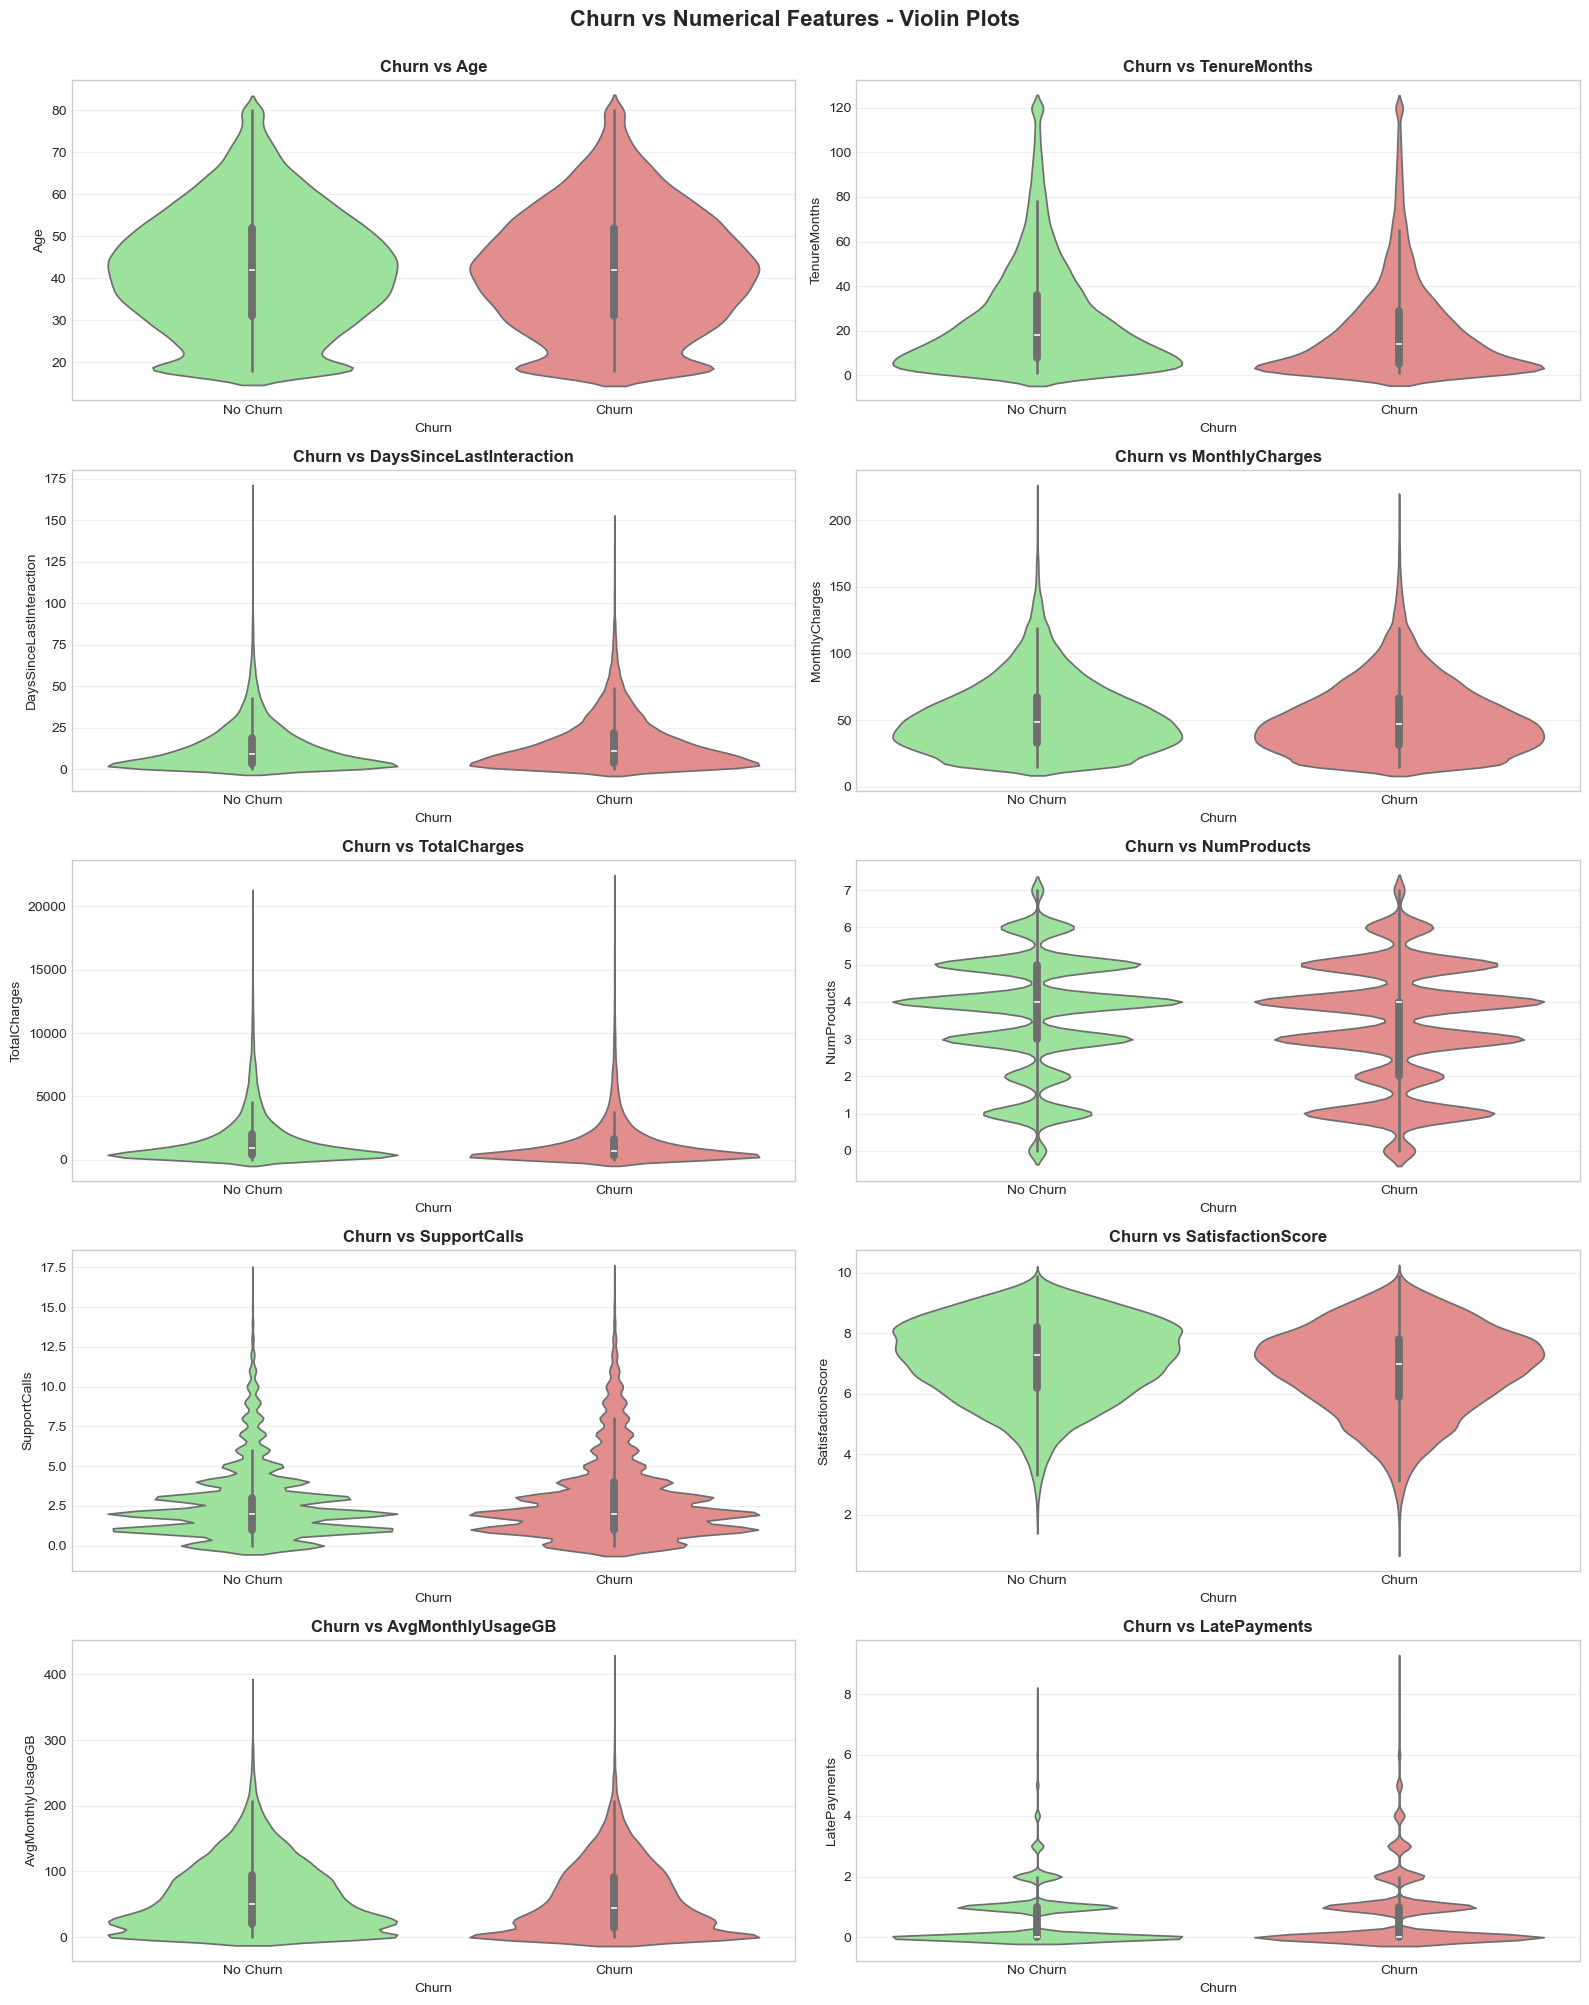


CHURN vs CATEGORICAL FEATURES


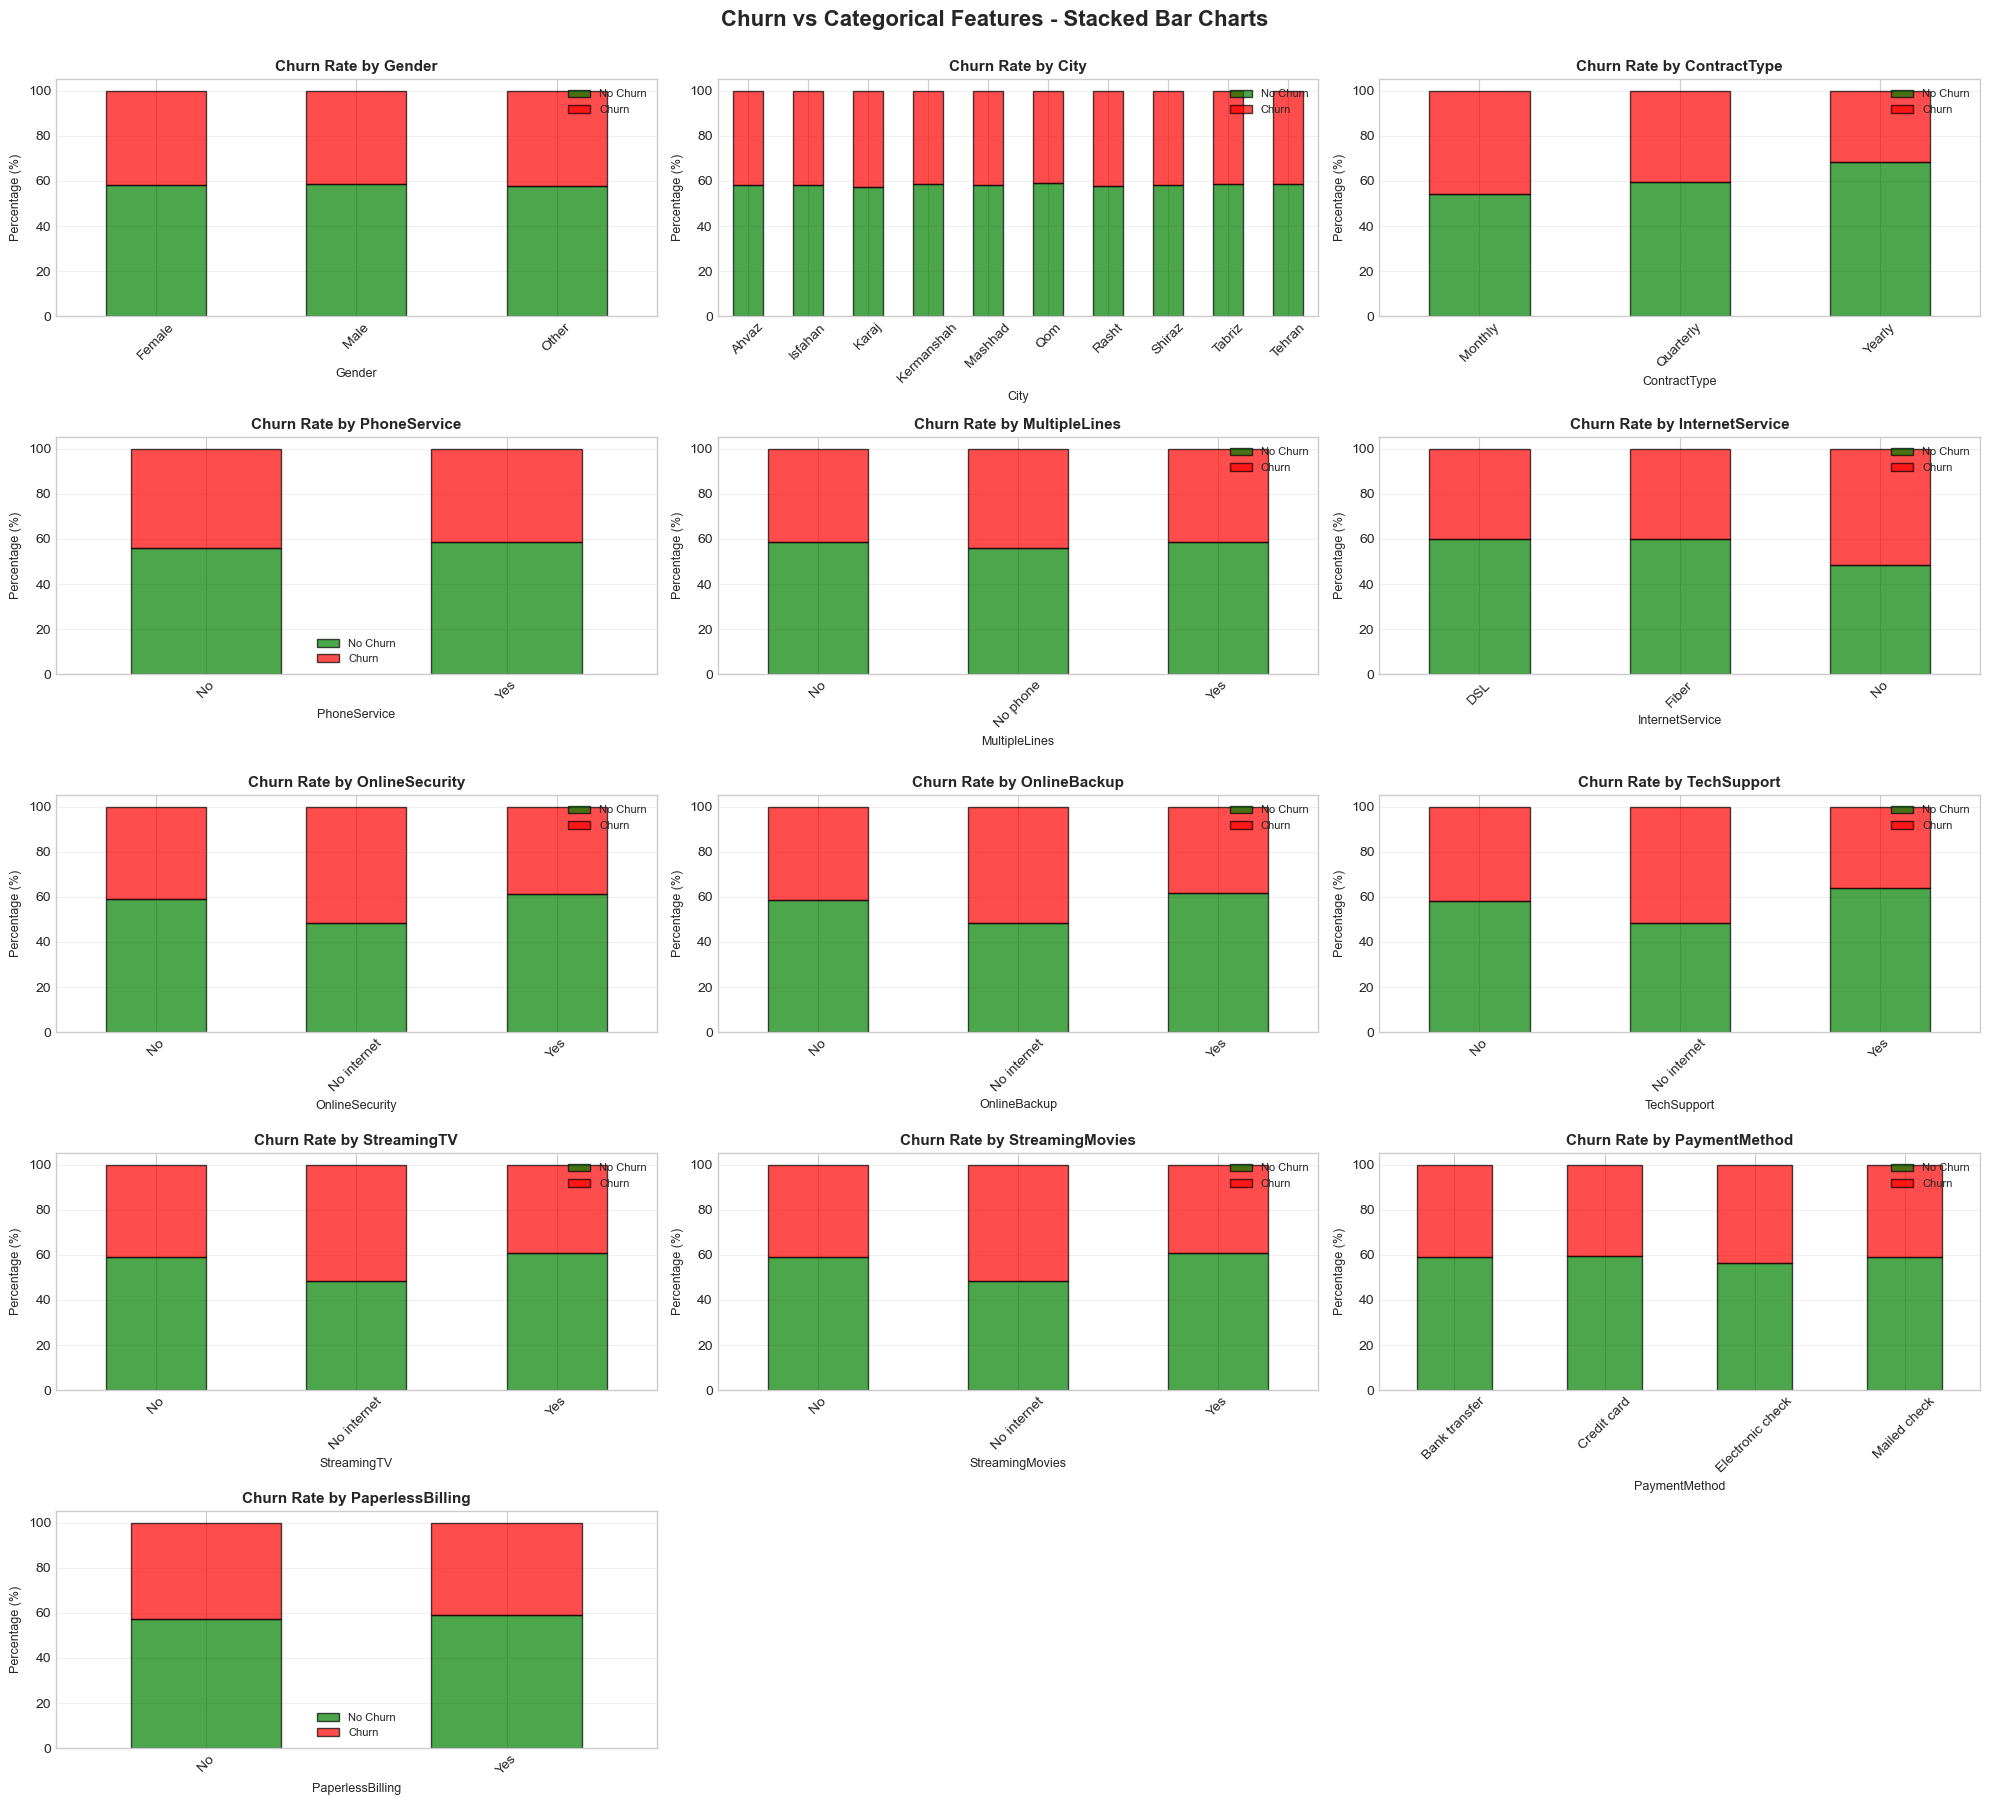


CHURN RATE BY CATEGORICAL FEATURES


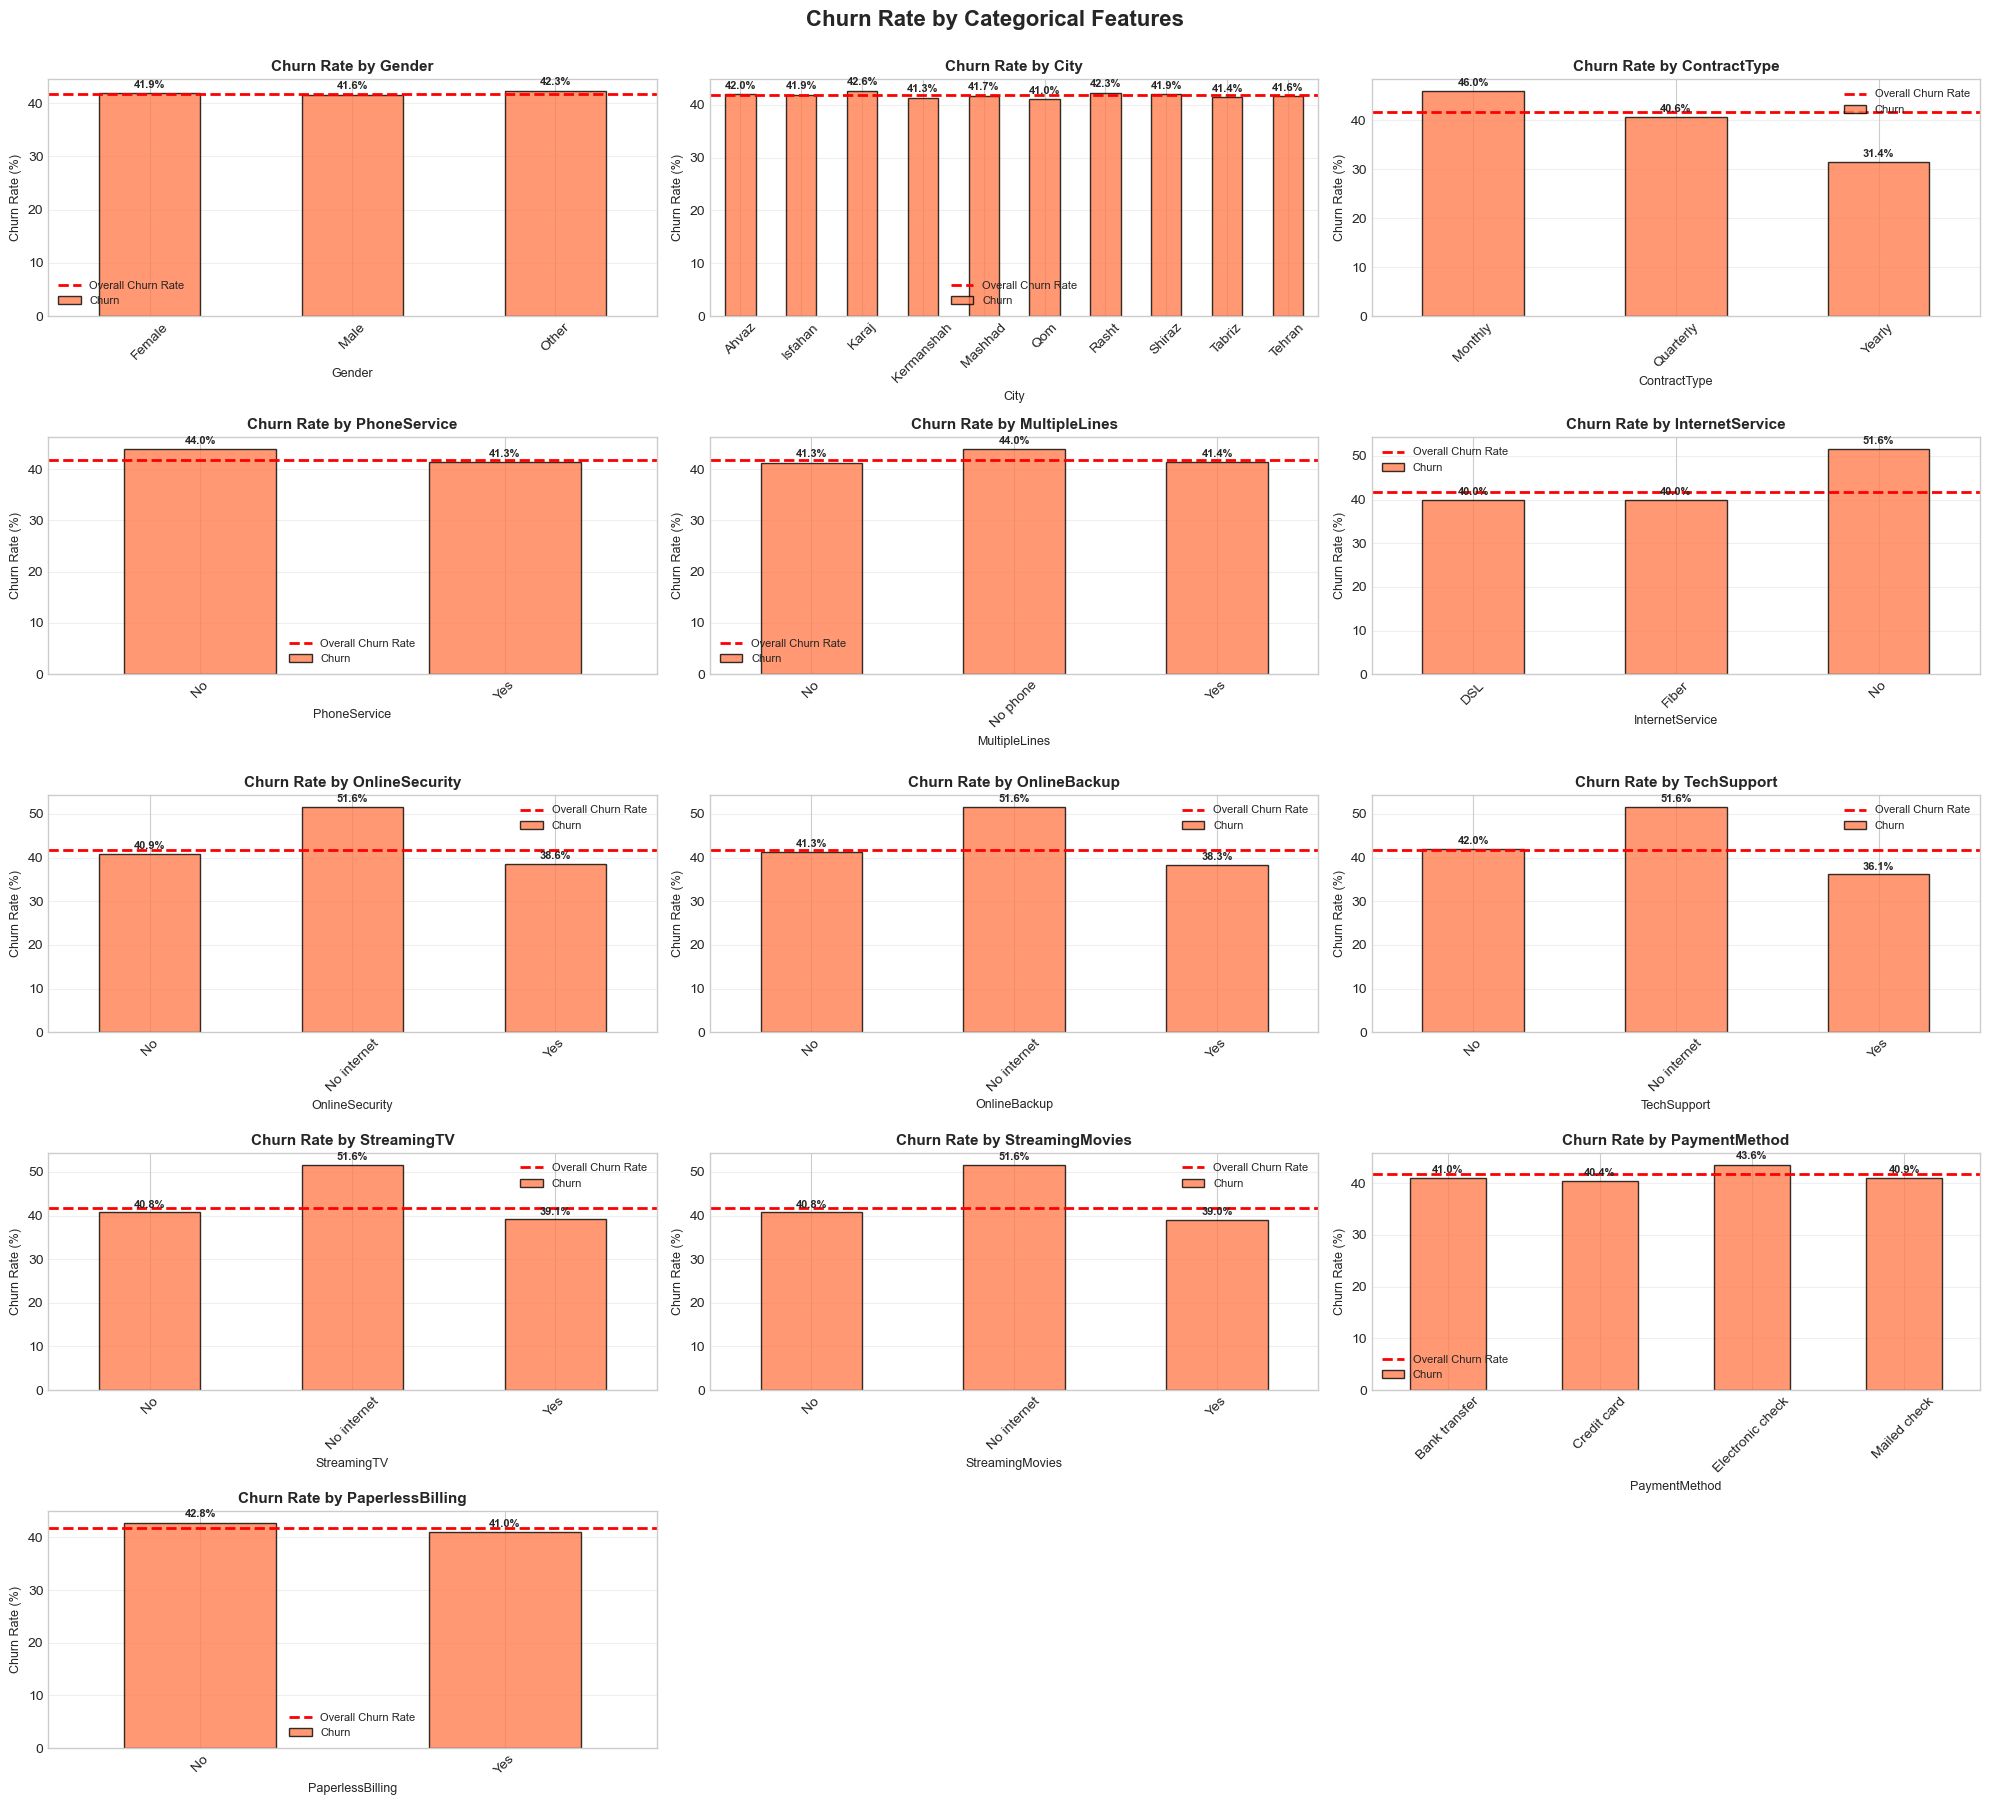


CHI-SQUARE TEST - CHURN vs CATEGORICAL FEATURES
         Feature  Chi-Square  P-Value  DOF Significant
    ContractType    903.3104   0.0000    2         Yes
     TechSupport    695.7653   0.0000    2         Yes
    OnlineBackup    557.7267   0.0000    2         Yes
  OnlineSecurity    534.1771   0.0000    2         Yes
 StreamingMovies    523.5750   0.0000    2         Yes
     StreamingTV    521.5363   0.0000    2         Yes
 InternetService    503.6033   0.0000    2         Yes
   PaymentMethod     52.3470   0.0000    3         Yes
   MultipleLines     25.9032   0.0000    2         Yes
    PhoneService     25.7000   0.0000    1         Yes
PaperlessBilling     21.5907   0.0000    1         Yes
            City      4.1295   0.9027    9          No
          Gender      0.8288   0.6607    2          No

CHURN RATE SUMMARY BY CATEGORICAL FEATURES

Gender:
        Total  Churned  Churn Rate
Gender                            
Other    1394      590       42.32
Female  35063    14684 

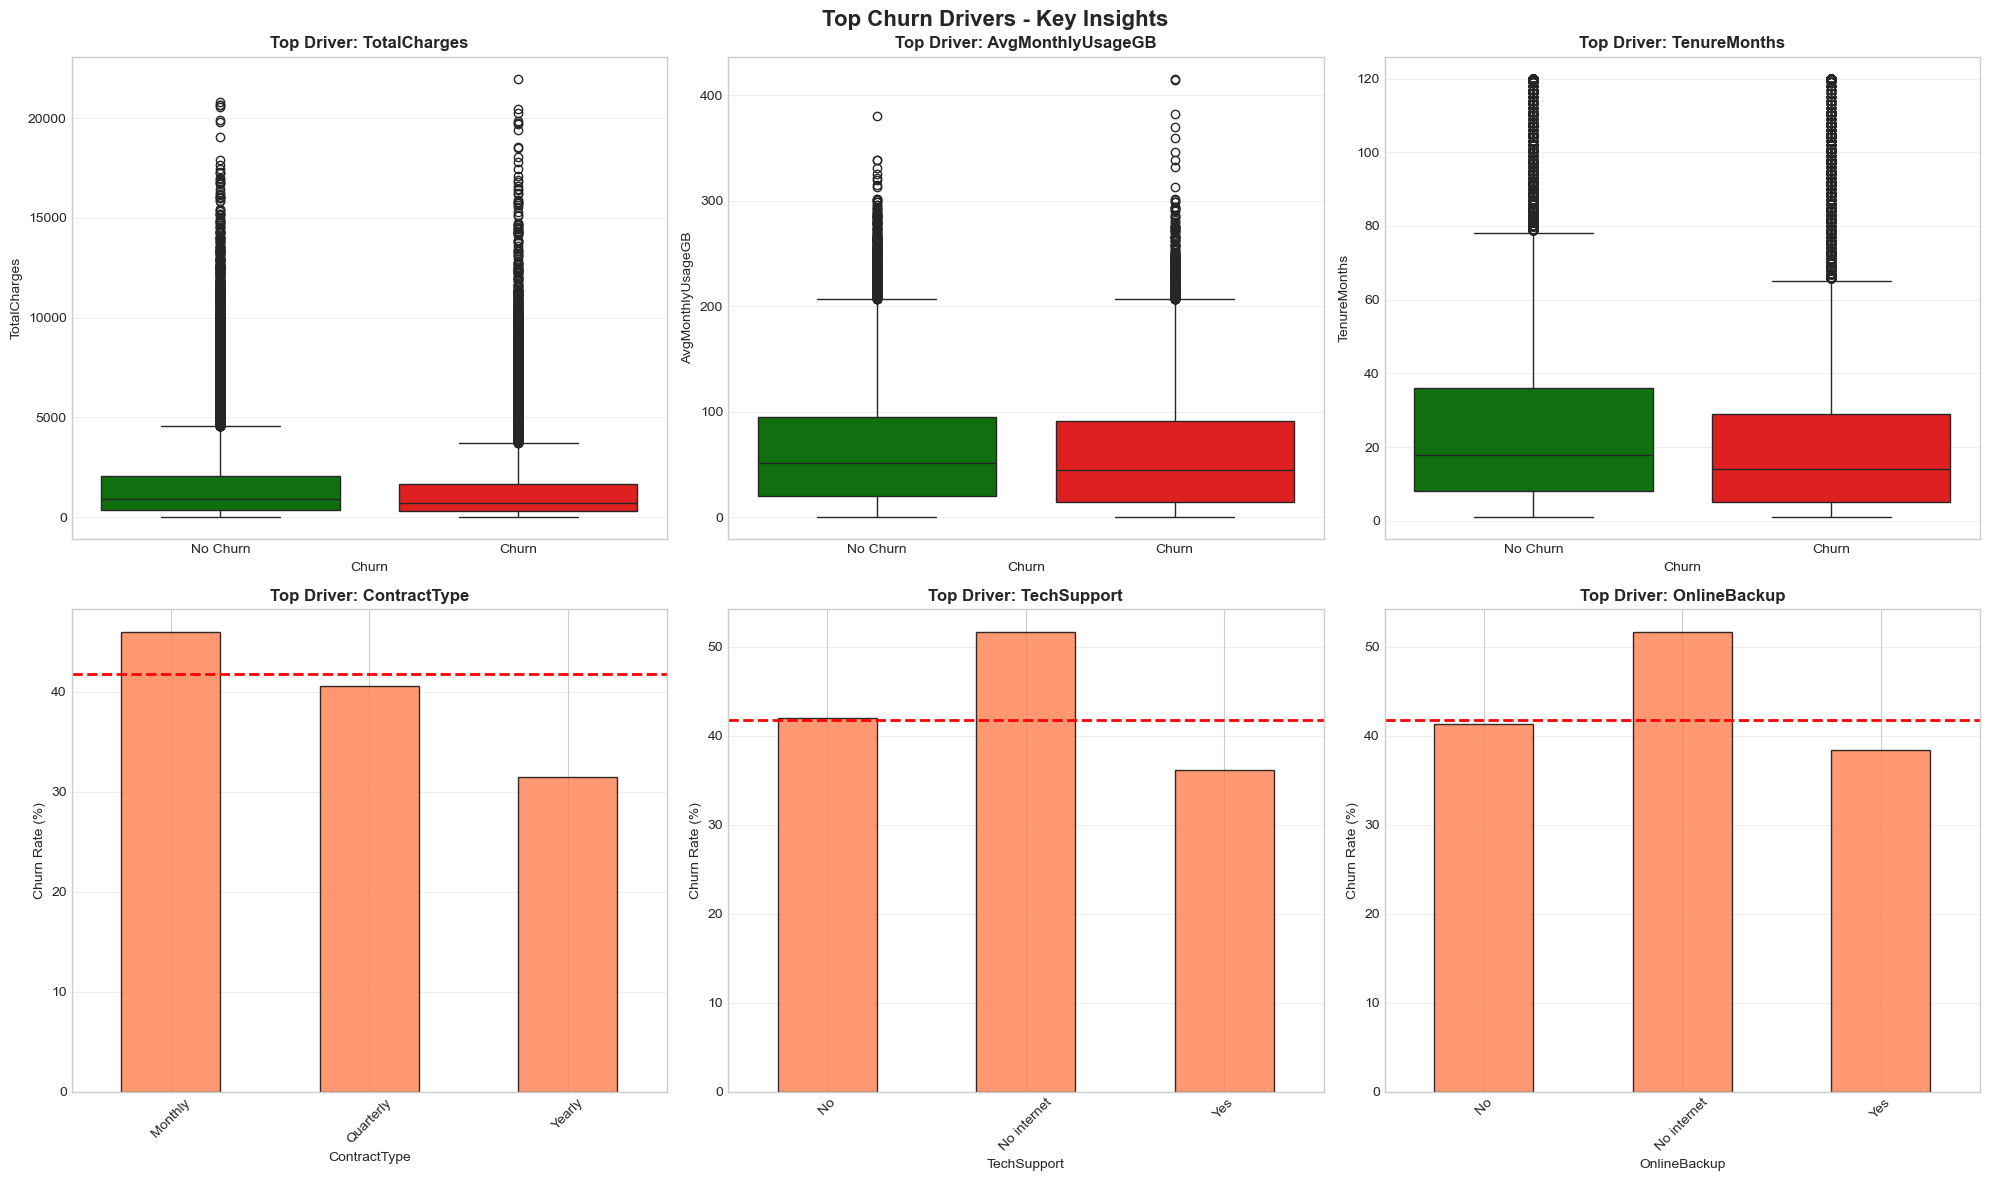


TARGET ANALYSIS COMPLETED


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 05: TARGET ANALYSIS - CHURN
# Purpose: Deep analysis of target variable and its relationships with features
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/raw/customer_churn_dataset.csv')

print("="*80)
print("TARGET ANALYSIS - CHURN")
print("="*80)
print(f"\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

numerical_cols = ['Age', 'TenureMonths', 'DaysSinceLastInteraction', 'MonthlyCharges', 
                  'TotalCharges', 'NumProducts', 'SupportCalls', 'SatisfactionScore', 
                  'AvgMonthlyUsageGB', 'LatePayments']

categorical_cols = ['Gender', 'City', 'ContractType', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'PaperlessBilling']

# ═══════════════════════════════════════════════════════════════════════════════
# 2. TARGET VARIABLE DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)

churn_counts = df['Churn'].value_counts()
churn_pcts = df['Churn'].value_counts(normalize=True) * 100

print(f"\nChurn Distribution:")
print(f"No Churn (0): {churn_counts[0]:,} ({churn_pcts[0]:.2f}%)")
print(f"Churn (1): {churn_counts[1]:,} ({churn_pcts[1]:.2f}%)")
print(f"\nChurn Rate: {churn_pcts[1]:.2f}%")
print(f"Class Imbalance Ratio: 1:{churn_counts[0]/churn_counts[1]:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Distribution - Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pcts.values)):
    axes[0].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
colors = ['lightgreen', 'lightcoral']
wedges, texts, autotexts = axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], 
                                        autopct='%1.1f%%', startangle=90, colors=colors,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Churn Distribution - Proportion', fontsize=12, fontweight='bold')

# Donut chart
axes[2].pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            startangle=90, colors=colors, wedgeprops=dict(width=0.4),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[2].set_title('Churn Distribution - Donut', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable Analysis: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/05_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. CHURN vs NUMERICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHURN vs NUMERICAL FEATURES")
print("="*80)

# Visualization boxplot for each numerical feature
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette=['green', 'red'])
    axes[idx].set_title(f'Churn vs {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # add mean lines
    no_churn_mean = df[df['Churn'] == 0][col].mean()
    churn_mean = df[df['Churn'] == 1][col].mean()
    axes[idx].axhline(no_churn_mean, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[idx].axhline(churn_mean, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.suptitle('Churn vs Numerical Features - Boxplots', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/05_churn_numerical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. STATISTICAL TESTS - NUMERICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("STATISTICAL TESTS - CHURN vs NUMERICAL FEATURES")
print("="*80)

stat_results = []

for col in numerical_cols:
    no_churn_data = df[df['Churn'] == 0][col].dropna()
    churn_data = df[df['Churn'] == 1][col].dropna()
    
    # T-test
    t_stat, t_pval = ttest_ind(no_churn_data, churn_data)
    
    # Mann-Whitney U test (non-parametric)
    u_stat, u_pval = mannwhitneyu(no_churn_data, churn_data)
    
    stat_results.append({
        'Feature': col,
        'No Churn Mean': no_churn_data.mean(),
        'Churn Mean': churn_data.mean(),
        'Mean Diff': churn_data.mean() - no_churn_data.mean(),
        'T-Test P-Value': t_pval,
        'Mann-Whitney P-Value': u_pval,
        'Significant': 'Yes' if t_pval < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stat_results).sort_values('Mean Diff', key=abs, ascending=False)
print(stat_df.round(4).to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 5. CHURN vs NUMERICAL FEATURES - VIOLIN PLOTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHURN vs NUMERICAL FEATURES - VIOLIN PLOTS")
print("="*80)

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.violinplot(x='Churn', y=col, data=df, ax=axes[idx], palette=['lightgreen', 'lightcoral'])
    axes[idx].set_title(f'Churn vs {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    axes[idx].set_xticklabels(['No Churn', 'Churn'])
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Churn vs Numerical Features - Violin Plots', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/05_churn_numerical_violins.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. CHURN vs CATEGORICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHURN vs CATEGORICAL FEATURES")
print("="*80)

# Visualization stacked bar charts
fig, axes = plt.subplots(5, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    churn_by_cat = df.groupby(col)['Churn'].agg(['sum', 'count'])
    churn_by_cat['churn_rate'] = (churn_by_cat['sum'] / churn_by_cat['count']) * 100
    
    # Stacked bar
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['green', 'red'], 
            edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Percentage (%)', fontsize=9)
    axes[idx].legend(['No Churn', 'Churn'], fontsize=8)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Churn vs Categorical Features - Stacked Bar Charts', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/05_churn_categorical_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. CHURN RATE BY CATEGORICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHURN RATE BY CATEGORICAL FEATURES")
print("="*80)

fig, axes = plt.subplots(5, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    # churn rate
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    
    # Bar plot
    churn_rate.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].axhline(df['Churn'].mean() * 100, color='red', linestyle='--', 
                      linewidth=2, label='Overall Churn Rate')
    axes[idx].legend(fontsize=8)
    
    for i, v in enumerate(churn_rate.values):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

for idx in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/05_churn_rate_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 8. CHI-SQUARE TEST - CATEGORICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHI-SQUARE TEST - CHURN vs CATEGORICAL FEATURES")
print("="*80)

chi_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_results.append({
        'Feature': col,
        'Chi-Square': chi2,
        'P-Value': p_value,
        'DOF': dof,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values('Chi-Square', ascending=False)
print(chi_df.round(4).to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 9. CHURN RATE SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHURN RATE SUMMARY BY CATEGORICAL FEATURES")
print("="*80)

for col in categorical_cols:
    print(f"\n{col}:")
    churn_summary = df.groupby(col)['Churn'].agg(['count', 'sum', 'mean'])
    churn_summary.columns = ['Total', 'Churned', 'Churn Rate']
    churn_summary['Churn Rate'] = churn_summary['Churn Rate'] * 100
    churn_summary = churn_summary.sort_values('Churn Rate', ascending=False)
    print(churn_summary.round(2).to_string())

# ═══════════════════════════════════════════════════════════════════════════════
# 10. KEY INSIGHTS VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("KEY INSIGHTS - TOP CHURN DRIVERS")
print("="*80)

# top features 
top_numerical = stat_df.head(5)['Feature'].tolist()
top_categorical = chi_df.head(5)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Top 5 numerical features
for idx, col in enumerate(top_numerical):
    if idx < 3:
        sns.boxplot(x='Churn', y=col, data=df, ax=axes[0, idx], palette=['green', 'red'])
        axes[0, idx].set_title(f'Top Driver: {col}', fontsize=12, fontweight='bold')
        axes[0, idx].set_xticklabels(['No Churn', 'Churn'])
        axes[0, idx].grid(axis='y', alpha=0.3)

# Top 3 categorical features
for idx, col in enumerate(top_categorical[:3]):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[1, idx], color='coral', edgecolor='black', alpha=0.8)
    axes[1, idx].set_title(f'Top Driver: {col}', fontsize=12, fontweight='bold')
    axes[1, idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[1, idx].tick_params(axis='x', rotation=45)
    axes[1, idx].grid(axis='y', alpha=0.3)
    axes[1, idx].axhline(df['Churn'].mean() * 100, color='red', linestyle='--', linewidth=2)

plt.suptitle('Top Churn Drivers - Key Insights', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/05_top_churn_drivers.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("TARGET ANALYSIS COMPLETED")
print("="*80)
